# Para esta Tarea

Generar un archivo tipo Notebook de Python que contenga: 

- Importación del archivo de uso (Datos de Marketing para un Banco) https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset
- Exploración básica EDA usando pandas: tail, sample, shape, info 
- Validar si es que existen nulos o información vacía, tipo de datos, describe, nunique
- Correlación y heat map, visualización de distribución sns.distplot
- Eliminar variables que tengan alta correlación y/o no sean necesarias
- Reportes por grupos : estado civil, educación, trabajo – cuántos registros
- Análisis univariado y bivariado basado en la predicción (y/n)
- Dividir dataset entre training y test (70:30) 

---

# Desarrollo

## Importacion de librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Lectura del CSV

In [48]:
df = pd.read_csv('../../../Archivos-Analisis/files-tarea-m41/bank-additional-full.csv', sep=';')
df.sample(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
25710,51,admin.,married,university.degree,no,yes,no,cellular,nov,wed,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
16501,36,services,married,high.school,unknown,no,no,cellular,jul,wed,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.963,5228.1,no
26784,30,services,married,basic.9y,no,yes,no,cellular,nov,thu,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.076,5195.8,no
14168,39,admin.,married,university.degree,no,no,no,cellular,jul,mon,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14897,43,blue-collar,single,basic.6y,no,yes,no,cellular,jul,wed,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.957,5228.1,no
25790,42,entrepreneur,single,university.degree,no,no,no,cellular,nov,wed,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
29011,41,blue-collar,married,basic.9y,no,no,yes,cellular,apr,fri,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.405,5099.1,no
3206,42,blue-collar,divorced,basic.4y,unknown,yes,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.860,5191.0,no
40470,75,retired,married,basic.4y,no,no,no,cellular,aug,wed,...,2,6,3,success,-1.7,94.027,-38.3,0.903,4991.6,yes
34673,34,unemployed,married,basic.9y,no,yes,no,cellular,may,thu,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.266,5099.1,no


## EDA

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [9]:
df.dtypes

age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duration,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
campaign,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
pdays,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
previous,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
emp.var.rate,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
nr.employed,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


In [12]:
df.shape

(41188, 21)

In [13]:
df.nunique().sort_values()

y                    2
contact              2
default              3
housing              3
loan                 3
poutcome             3
marital              4
day_of_week          5
education            8
previous             8
emp.var.rate        10
month               10
nr.employed         11
job                 12
cons.price.idx      26
cons.conf.idx       26
pdays               27
campaign            42
age                 78
euribor3m          316
duration          1544
dtype: int64

## Deteccion de valores nulos

In [8]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

No se detectaron valores nulos o con valores NAN

## Cambio de tipo de valor de las columnas object a category

In [49]:
obj_columns = df.select_dtypes(include='object').columns
df[obj_columns] = df[obj_columns].astype('category')
df.dtypes

age                  int64
job               category
marital           category
education         category
default           category
housing           category
loan              category
contact           category
month             category
day_of_week       category
duration             int64
campaign             int64
pdays                int64
previous             int64
poutcome          category
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx      float64
euribor3m          float64
nr.employed        float64
y                 category
dtype: object

Insights
- El docuemnto base presenta una informacion bastante clara y limpia, por lo que las modificaciones a realizar no seran demaciadas
- De igual forma, todas las columnas manejan mas de 2 valores unicos, por lo que no sere de momento eliminar alguna de ellas

---

## Analisis Univariado

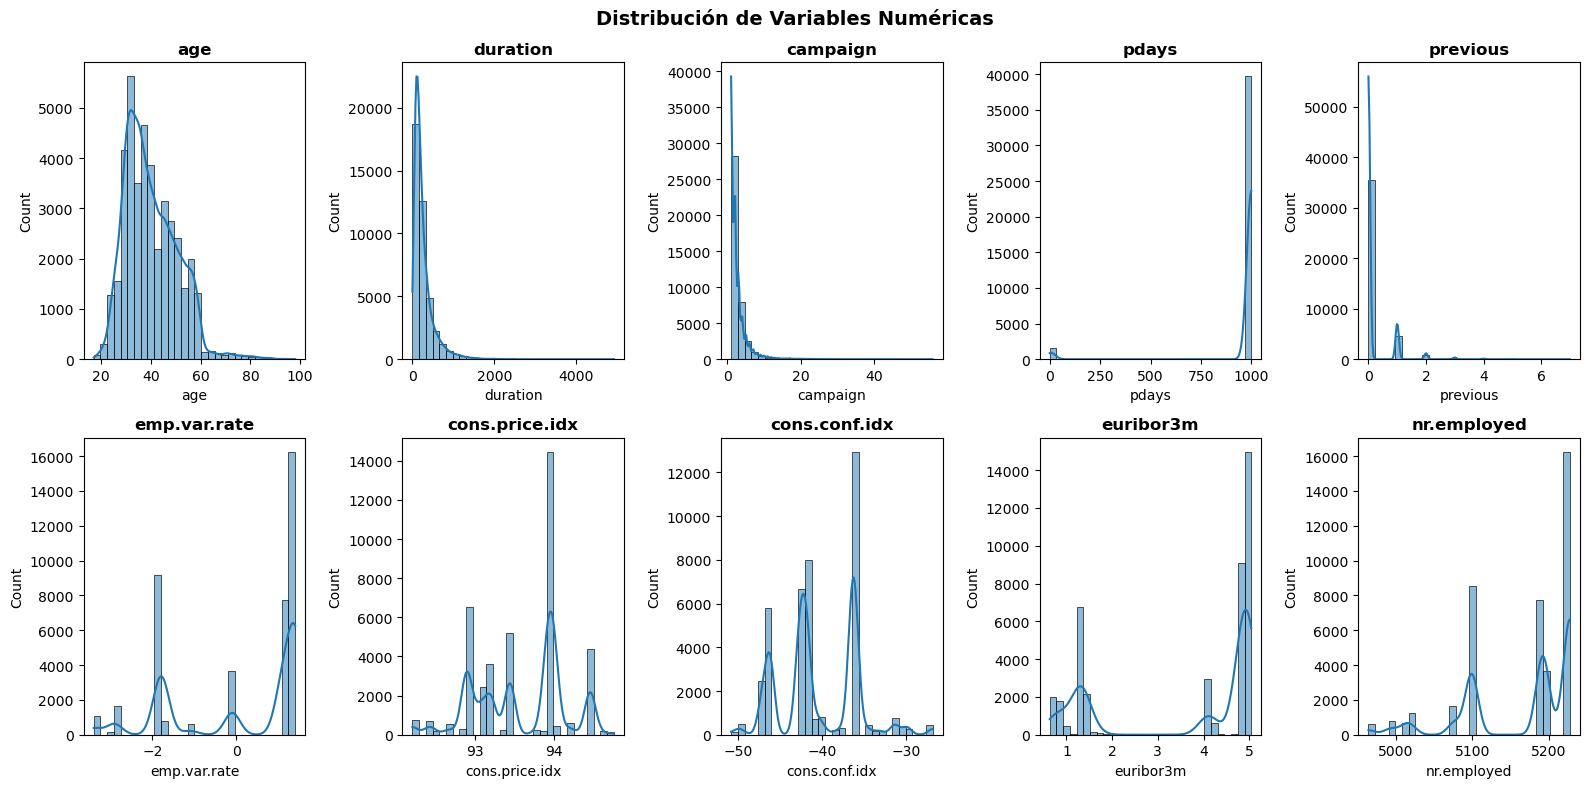

In [50]:
# Análisis Univariado - Variables Numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
fig, axes = plt.subplots(2, 5, figsize=(16, 8))
fig.suptitle('Distribución de Variables Numéricas', fontsize=14, fontweight='bold')

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 5, idx % 5]
    sns.histplot(df[col], ax=ax, kde=True, bins=30)
    ax.set_title(col, fontweight='bold')

plt.tight_layout()
plt.show()

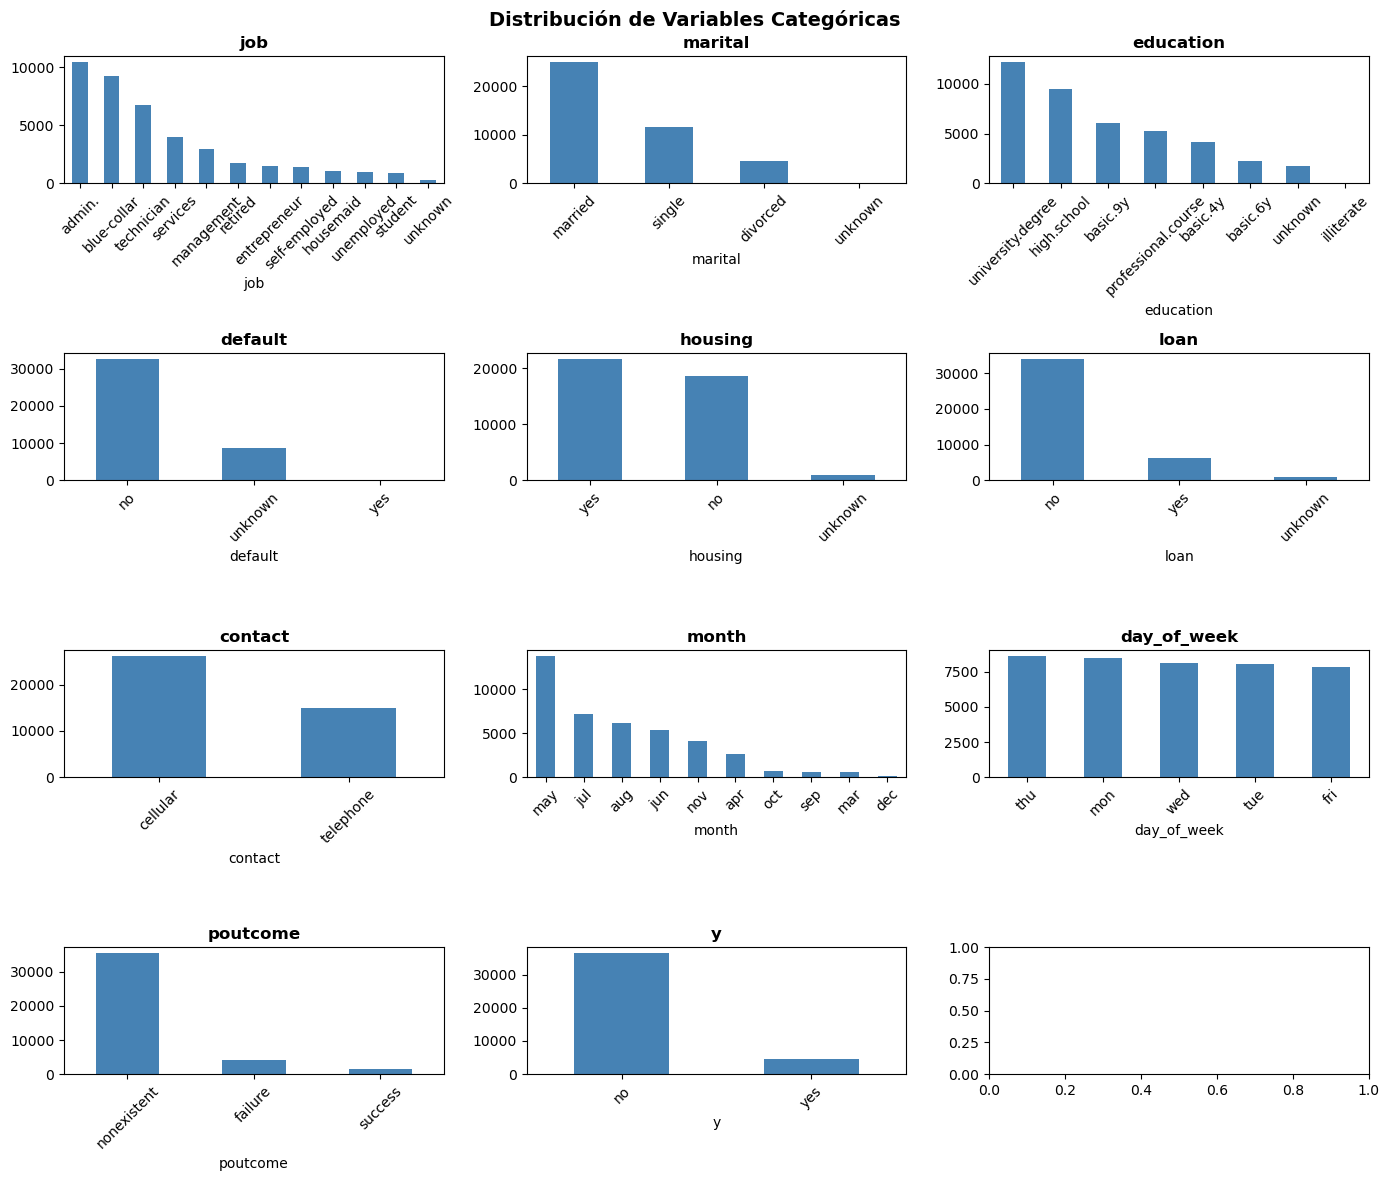

In [18]:
# Análisis Univariado - Variables Categóricas
categorical_cols = df.select_dtypes(include=['category']).columns
fig, axes = plt.subplots(4, 3, figsize=(14, 12))
fig.suptitle('Distribución de Variables Categóricas', fontsize=14, fontweight='bold')

for idx, col in enumerate(categorical_cols):
    ax = axes[idx // 3, idx % 3]
    df[col].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(col, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

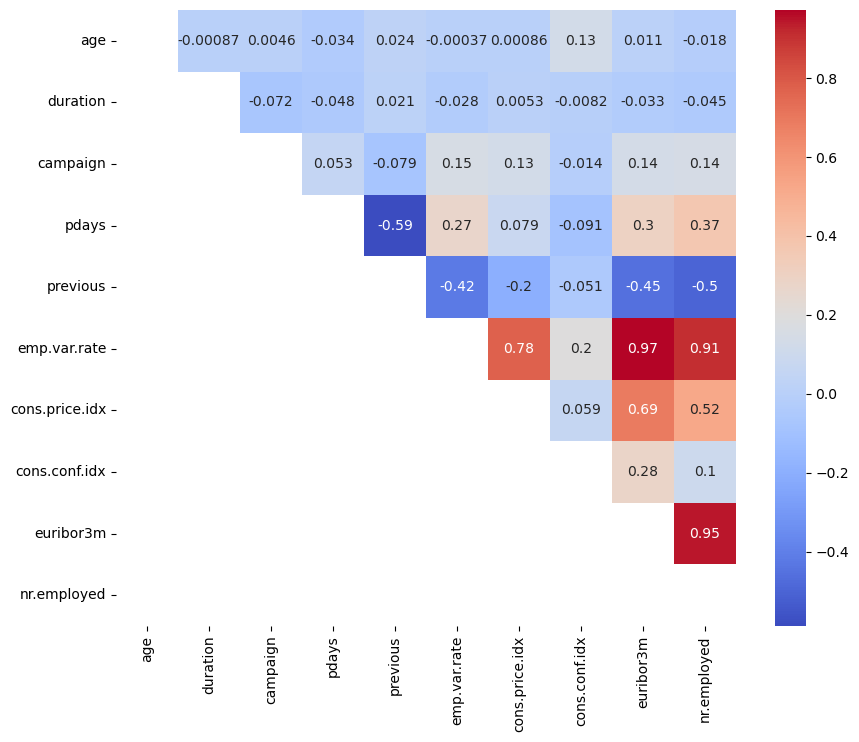

In [20]:
# GRafico de correlacion
plt.figure(figsize=(10, 8))
corr_df = corr = df.select_dtypes(include=[np.number]).corr(method='pearson')
df_lt = corr_df.mask(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='coolwarm', annot=True)

Insigths
- Las columnas nr.employed, euribor3m, cost.price.idx, son las que mas correlacion tienen ante emp.var.rate

---

### Busqueda de Outliners

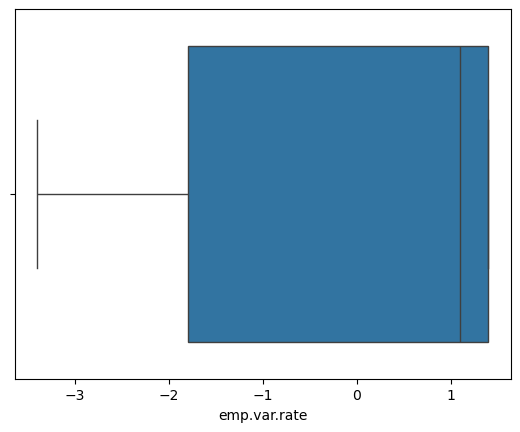

In [21]:
ax = sns.boxplot(x = df['emp.var.rate'])

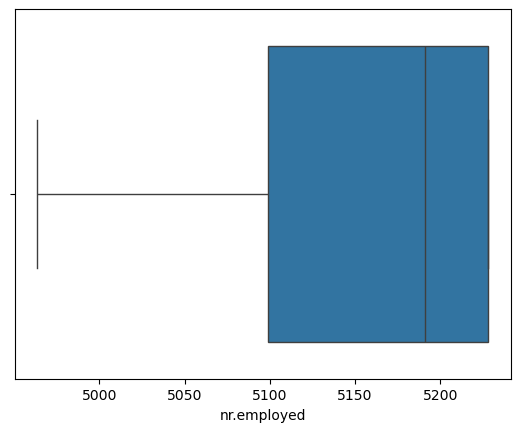

In [22]:
ax = sns.boxplot(x = df['nr.employed'])


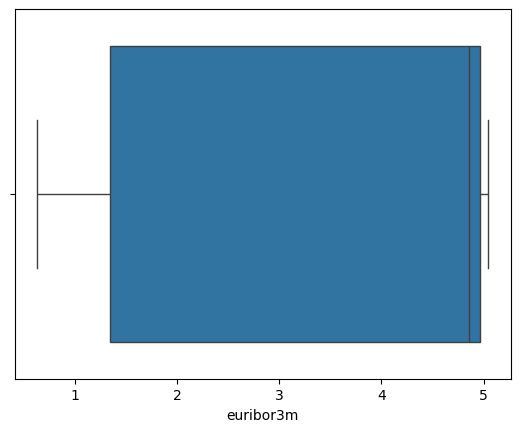

In [24]:
ax = sns.boxplot(x = df['euribor3m'])

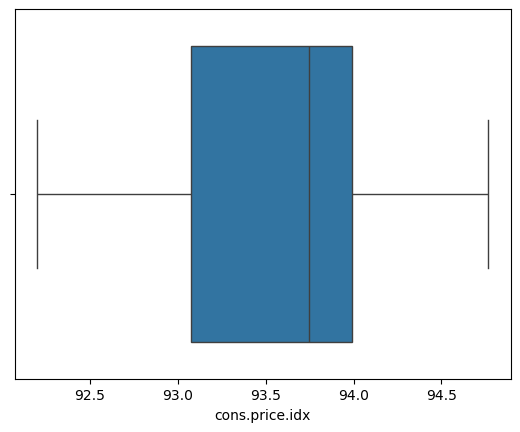

In [26]:
ax = sns.boxplot(x = df['cons.price.idx'])

---

## Analisis Bivariado

In [51]:
df.groupby(['marital']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\3454757394.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['marital']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\3454757394.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['marital']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)


age                 40.02
duration           258.29
campaign             2.57
pdays              962.48
previous             0.17
emp.var.rate         0.08
cons.price.idx      93.58
cons.conf.idx      -40.50
euribor3m            3.62
nr.employed       5167.04
dtype: float64

In [60]:
df.groupby(['job']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\3071674003.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['job']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\3071674003.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['job']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)


age                 40.02
duration           258.29
campaign             2.57
pdays              962.48
previous             0.17
emp.var.rate         0.08
cons.price.idx      93.58
cons.conf.idx      -40.50
euribor3m            3.62
nr.employed       5167.04
dtype: float64

In [61]:
df.groupby(['education']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\4294785537.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['education']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\4294785537.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['education']).apply(lambda x: x.select_dtypes(include=[np.number])).mean().round(2)


age                 40.02
duration           258.29
campaign             2.57
pdays              962.48
previous             0.17
emp.var.rate         0.08
cons.price.idx      93.58
cons.conf.idx      -40.50
euribor3m            3.62
nr.employed       5167.04
dtype: float64

In [52]:
df.groupby(['y']).apply(lambda x: x.select_dtypes(include=[np.number]).median()).round(2).T

C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\1166859804.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['y']).apply(lambda x: x.select_dtypes(include=[np.number]).median()).round(2).T
C:\Users\RyanHz\AppData\Local\Temp\ipykernel_19388\1166859804.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(['y']).apply(lambda x: x.select_dtypes(include=[np.number]).median()).round(2).T


y,no,yes
age,38.00,37.00
duration,163.50,449.00
campaign,2.00,2.00
pdays,999.00,999.00
previous,0.00,0.00
emp.var.rate,1.10,-1.80
cons.price.idx,93.92,93.20
cons.conf.idx,-41.80,-40.40
euribor3m,4.86,1.27
nr.employed,5195.80,5099.10


---

## Antes del Split

In [53]:
df_cp = df.copy()

In [54]:
df_cp.drop(['emp.var.rate', 'nr.employed', 'euribor3m', 'cons.price.idx'], axis=1, inplace=True)

In [55]:
df_cp

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,cons.conf.idx,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,-36.4,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,-36.4,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,-36.4,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,-36.4,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,-36.4,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,334,1,999,0,nonexistent,-50.8,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,383,1,999,0,nonexistent,-50.8,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,189,2,999,0,nonexistent,-50.8,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,442,1,999,0,nonexistent,-50.8,yes


In [56]:
# Generamos las variables trnafosmadas logarimicamente
# Para variables que tienen el sesgo alto
df_cp['campaign-log'] = np.log(df_cp['campaign'] + 1)
df_cp['age-log'] = np.log(df_cp['age'] + 1)
df_cp['duration-log'] = np.log(df_cp['duration'] + 1)
df_cp['pdays-log'] = np.log(df_cp['pdays'] + 1)
df_cp['previous-log'] = np.log(df_cp['previous'] + 1)

In [57]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
2191,27,blue-collar,married,basic.9y,unknown,no,no,telephone,may,mon,...,3,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
36621,53,unknown,married,professional.course,no,no,no,cellular,jun,thu,...,2,3,1,success,-2.9,92.963,-40.8,1.260,5076.2,no
25648,35,admin.,married,university.degree,no,yes,no,cellular,nov,wed,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.120,5195.8,no
15901,30,admin.,single,university.degree,no,no,no,cellular,jul,mon,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.960,5228.1,no
11252,23,technician,single,professional.course,no,unknown,unknown,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.961,5228.1,no


---

## Data Split

In [58]:
x = df_cp.drop('y', axis=1) # El array x no va a contemplar la respuesta
y = df_cp['y'] # Clase a predecir
# Se divide en X y Y en un ratio de 70:30

# Convertir categoricas en dummies
x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=1)

In [59]:
x_train.head(5)

,age,duration,campaign,pdays,previous,cons.conf.idx,campaign-log,age-log,duration-log,pdays-log,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
11196,38,149,1,999,0,-41.8,0.693147,3.663562,5.010635,6.907755,...,False,False,False,False,False,True,False,False,True,False
15464,51,104,1,999,0,-42.7,0.693147,3.951244,4.653960,6.907755,...,False,False,False,False,False,False,False,False,True,False
25538,45,770,1,999,0,-42.0,0.693147,3.828641,6.647688,6.907755,...,False,True,False,False,False,False,False,True,True,False
13108,45,394,1,999,0,-42.7,0.693147,3.828641,5.978886,6.907755,...,False,False,False,False,False,False,False,True,True,False
17088,34,1000,1,999,0,-42.7,0.693147,3.555348,6.908755,6.907755,...,False,False,False,False,False,False,False,False,True,False


---

# DataFrame de referencia

In [6]:
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes


---

# Diccionario de Datos – Bank Client Dataset

## Descripción general
Este dataset contiene información de clientes bancarios, detalles de campañas de marketing,
variables socioeconómicas y una variable objetivo relacionada con la suscripción
a un depósito a plazo.

---

## 🗂 Diccionario de Datos

| # | Columna | Descripción | Tipo | Valores / Categorías |
|---|--------|------------|------|----------------------|
| 1 | age | Edad del cliente | Numérico | Años |
| 2 | job | Tipo de trabajo | Categórico | admin., blue-collar, entrepreneur, housemaid, management, retired, self-employed, services, student, technician, unemployed, unknown |
| 3 | marital | Estado civil | Categórico | divorced, married, single, unknown |
| 4 | education | Nivel educativo | Categórico | basic.4y, basic.6y, basic.9y, high.school, illiterate, professional.course, university.degree, unknown |
| 5 | default | Crédito en incumplimiento | Categórico | no, yes, unknown |
| 6 | housing | Crédito hipotecario | Categórico | no, yes, unknown |
| 7 | loan | Préstamo personal | Categórico | no, yes, unknown |
| 8 | contact | Tipo de contacto | Categórico | cellular, telephone |
| 9 | month | Mes del último contacto | Categórico | jan, feb, mar, apr, may, jun, jul, aug, sep, oct, nov, dec |
| 10 | day_of_week | Día de la semana del último contacto | Categórico | mon, tue, wed, thu, fri |
| 11 | duration | Duración del último contacto (segundos) | Numérico | ≥ 0 |
| 12 | campaign | Contactos realizados en la campaña actual | Numérico | Entero ≥ 1 |
| 13 | pdays | Días desde el último contacto previo | Numérico | 0–999 (999 = no contactado previamente) |
| 14 | previous | Contactos antes de la campaña actual | Numérico | Entero ≥ 0 |
| 15 | poutcome | Resultado de la campaña anterior | Categórico | failure, nonexistent, success |
| 16 | emp.var.rate | Tasa de variación del empleo (trimestral) | Numérico | Continuo |
| 17 | cons.price.idx | Índice de precios al consumidor (mensual) | Numérico | Continuo |
| 18 | cons.conf.idx | Índice de confianza del consumidor (mensual) | Numérico | Continuo |
| 19 | euribor3m | Tasa Euribor a 3 meses (diaria) | Numérico | Continuo |
| 20 | nr.employed | Número de empleados (trimestral) | Numérico | Continuo |
| 21 | y | Suscripción a depósito a plazo | Binario | yes, no |

---

## 🎯 Variable Objetivo
- **`y`**: Indica si el cliente contrató un depósito a plazo.

---

## ⚠️ Notas
- La variable **`duration`** solo debe utilizarse para análisis descriptivo o benchmarking.
- Para modelos predictivos realistas, **debe excluirse `duration`**.
